In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [4]:
d = pd.read_csv('activities.csv')
d.head(5)

,Record_ID,Activity,Duration_Minutes,Difficulty,Group_Size,Age_Group,Indoor_Outdoor,Instructor,Rating
0,1,Yoga,30,Easy,5,8-Jun,Indoor,Alice,4.0
1,2,Coding,45,Medium,8,11-Sep,Indoor,Bob,5.0
2,3,Storytelling,20,Easy,10,8-Jun,Indoor,Carol,4.0
3,4,Chess,60,Hard,2,14-Dec,Indoor,Dave,5.0
4,5,Music,40,Medium,6,11-Sep,Indoor,Eve,3.0


In [5]:
d.info()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Record_ID         66 non-null     int64  
 1   Activity          66 non-null     str    
 2   Duration_Minutes  66 non-null     int64  
 3   Difficulty        66 non-null     str    
 4   Group_Size        66 non-null     int64  
 5   Age_Group         66 non-null     str    
 6   Indoor_Outdoor    66 non-null     str    
 7   Instructor        65 non-null     str    
 8   Rating            61 non-null     float64
dtypes: float64(1), int64(3), str(5)
memory usage: 4.8 KB


In [6]:
d.isna().sum()
d.dropna(inplace= True)

In [7]:
d.duplicated().sum()
d.isna().sum()

Record_ID           0
Activity            0
Duration_Minutes    0
Difficulty          0
Group_Size          0
Age_Group           0
Indoor_Outdoor      0
Instructor          0
Rating              0
dtype: int64

In [8]:
x = d.drop('Rating', axis=1)
y = d["Rating"]
x.shape

(60, 8)

In [9]:
x.head(5)

,Record_ID,Activity,Duration_Minutes,Difficulty,Group_Size,Age_Group,Indoor_Outdoor,Instructor
0,1,Yoga,30,Easy,5,8-Jun,Indoor,Alice
1,2,Coding,45,Medium,8,11-Sep,Indoor,Bob
2,3,Storytelling,20,Easy,10,8-Jun,Indoor,Carol
3,4,Chess,60,Hard,2,14-Dec,Indoor,Dave
4,5,Music,40,Medium,6,11-Sep,Indoor,Eve


In [10]:
y.shape

(60,)

In [11]:
le = LabelEncoder()
#x = le.fit_transform(x)
y = le.fit_transform(y)
y

array([1, 2, 1, 2, 0, 1, 2, 2, 1, 0, 2, 1, 1, 2, 1, 2, 0, 1, 2, 1, 2, 1,
       2, 0, 1, 2, 2, 1, 2, 0, 1, 2, 1, 2, 1, 2, 0, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 0, 1, 2, 1, 1, 2, 0, 1, 2, 1, 2])

In [12]:
ord = OrdinalEncoder()
x = ord.fit_transform(x)
x

array([[ 0.,  6.,  1.,  0.,  1.,  2.,  0.,  0.],
       [ 1.,  2.,  3.,  2.,  4.,  0.,  0.,  1.],
       [ 2.,  5.,  0.,  0.,  5.,  2.,  0.,  2.],
       [ 3.,  1.,  5.,  1.,  0.,  1.,  0.,  3.],
       [ 4.,  4.,  2.,  2.,  2.,  0.,  0.,  4.],
       [ 5.,  3.,  4.,  2.,  5.,  1.,  0.,  5.],
       [ 6.,  0.,  1.,  0.,  3.,  2.,  0.,  6.],
       [ 7.,  2.,  3.,  2.,  4.,  0.,  0.,  1.],
       [ 8.,  6.,  1.,  0.,  1.,  2.,  0.,  0.],
       [ 9.,  4.,  2.,  2.,  2.,  0.,  0.,  4.],
       [10.,  1.,  5.,  1.,  0.,  1.,  0.,  3.],
       [11.,  5.,  0.,  0.,  5.,  2.,  0.,  2.],
       [12.,  3.,  4.,  2.,  5.,  1.,  0.,  5.],
       [13.,  0.,  1.,  0.,  3.,  2.,  0.,  6.],
       [14.,  6.,  1.,  0.,  1.,  2.,  0.,  0.],
       [15.,  2.,  3.,  2.,  4.,  0.,  0.,  1.],
       [16.,  4.,  2.,  2.,  2.,  0.,  0.,  4.],
       [17.,  3.,  4.,  2.,  5.,  1.,  0.,  5.],
       [18.,  0.,  1.,  0.,  3.,  2.,  0.,  6.],
       [19.,  6.,  1.,  0.,  1.,  2.,  0.,  0.],
       [20.,  2.,  3

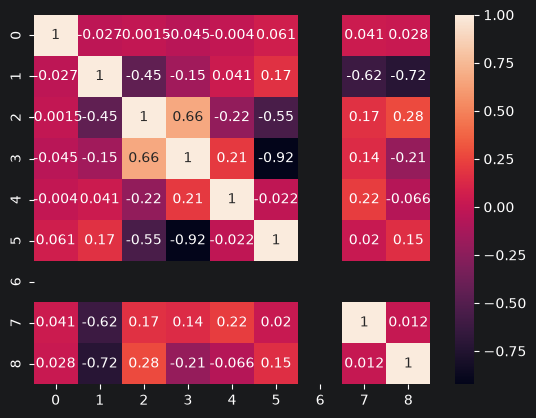

In [13]:
dn = np.column_stack((x,y))
dn = pd.DataFrame(dn)
sns.heatmap(dn.corr(), annot=True)
plt.show()

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [15]:
lr = LogisticRegression()
lr.fit(x_train, y_train)
Lpred = lr.predict(x_test)

/home/suupatruupa/Documents/hmph/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
x_test.shape

(12, 8)

In [17]:
Lpred.shape

(12,)

In [18]:
print(accuracy_score(y_test, Lpred))
print(classification_report(y_test, Lpred))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



In [19]:
KN = KNeighborsClassifier()
KN.fit(x_train, y_train)
Kpred = KN.predict(x_test)

In [20]:
print(accuracy_score(y_test, Kpred))
print(classification_report(y_test, Kpred))

0.25
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.40      0.40      0.40         5
           2       0.33      0.17      0.22         6

    accuracy                           0.25        12
   macro avg       0.24      0.19      0.21        12
weighted avg       0.33      0.25      0.28        12

